Sharon Xolocotzi Castillo

In [ ]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 14.1 MB/s eta 0:00:00


In [ ]:
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from arch import arch_model
import numpy as np
import pandas as pd
import gdown
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Serie original

## Extracción y procesamiento de datos

In [ ]:
#Carga del conjunto de datos
file_id = "1qLoQcC2ioZ6Bsm-nGa_1NKEpvRTGxz-R"
url = f"https://drive.google.com/uc?id={file_id}"
output = "Datos.csv"
gdown.download(url, output, quiet=False)
df = pd.read_csv(output)
df.head()

Downloading...
From: https://drive.google.com/uc?id=1qLoQcC2ioZ6Bsm-nGa_1NKEpvRTGxz-R
To: /content/Datos.csv
100%|██████████| 231k/231k [00:00<00:00, 4.58MB/s]


,Fecha,Cierre,Apertura,Máximo,Mínimo,Vol.,% var.
0,25.09.2025,18.4865,18.4500,18.5690,18.3766,NaN,0.30%
1,24.09.2025,18.4320,18.3595,18.4615,18.3231,NaN,0.39%
2,23.09.2025,18.3595,18.3559,18.3980,18.2996,NaN,0.02%
3,22.09.2025,18.3559,18.4315,18.4440,18.3394,NaN,-0.36%
4,21.09.2025,18.4216,18.4170,18.4277,18.4067,NaN,0.09%


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3585 entries, 0 to 3584
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Fecha     3585 non-null   object 
 1   Cierre    3585 non-null   float64
 2   Apertura  3585 non-null   float64
 3   Máximo    3585 non-null   float64
 4   Mínimo    3585 non-null   float64
 5   Vol.      0 non-null      float64
 6   % var.    3585 non-null   object 
dtypes: float64(5), object(2)
memory usage: 196.2+ KB


In [ ]:
#Convertir fecha
df["Fecha"] = pd.to_datetime(df["Fecha"], dayfirst=True)

In [ ]:
df.describe()

,Fecha,Cierre,Apertura,Máximo,Mínimo,Vol.
count,3585,3585.000000,3585.000000,3585.000000,3585.000000,0.0
mean,2018-11-13 23:57:59.497907712,17.719888,17.726953,17.837775,17.629460,NaN
min,2012-01-02 00:00:00,11.976700,11.976900,12.049300,11.935500,NaN
25%,2015-06-09 00:00:00,15.480300,15.470500,15.539500,15.386000,NaN
50%,2018-11-14 00:00:00,18.658600,18.662000,18.780200,18.579300,NaN
75%,2022-04-21 00:00:00,19.870000,19.885000,19.986500,19.795600,NaN
max,2025-09-25 00:00:00,25.338000,25.360600,25.757300,24.673200,NaN
std,NaN,2.883266,2.887380,2.922659,2.855893,NaN


In [ ]:
df.shape

(3585, 7)

In [ ]:
df.head()

,Fecha,Cierre,Apertura,Máximo,Mínimo,Vol.,% var.
0,2025-09-25,18.4865,18.4500,18.5690,18.3766,NaN,0.30%
1,2025-09-24,18.4320,18.3595,18.4615,18.3231,NaN,0.39%
2,2025-09-23,18.3595,18.3559,18.3980,18.2996,NaN,0.02%
3,2025-09-22,18.3559,18.4315,18.4440,18.3394,NaN,-0.36%
4,2025-09-21,18.4216,18.4170,18.4277,18.4067,NaN,0.09%


## Selección de variable

In [ ]:
#Eliminar variables con las que no trabajaremos
df = df.drop(columns=["Apertura", "Máximo", "Mínimo", "Vol.", "% var."])

In [ ]:
#Ordenar por fecha
df = df.sort_values("Fecha").reset_index(drop=True)
#Colocar Fecha como índice
df = df.set_index("Fecha")

In [ ]:
df.head()

,Cierre
Fecha,
2012-01-02,13.9080
2012-01-03,13.6490
2012-01-04,13.6625
2012-01-05,13.7544
2012-01-06,13.7190


## Visualización de la serie de tiempo

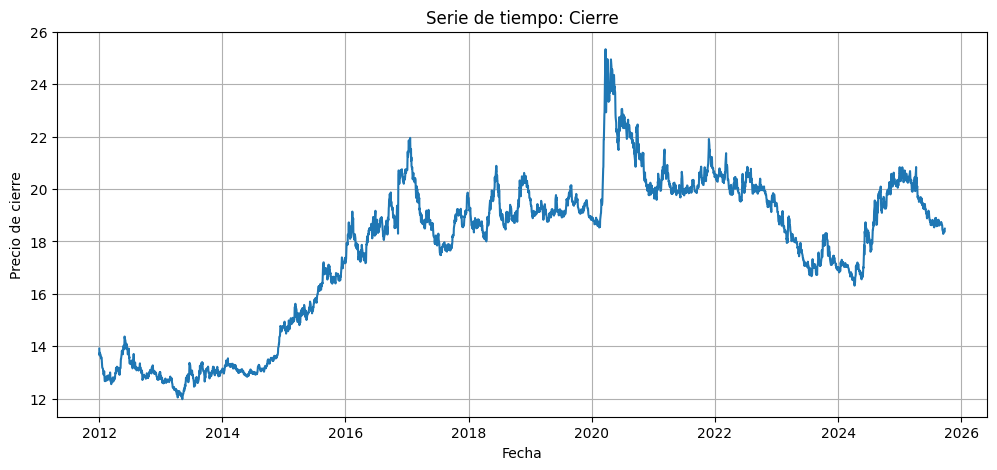

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df["Cierre"])
plt.title("Serie de tiempo: Cierre")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.grid(True)
plt.show()

## Análisis de componentes

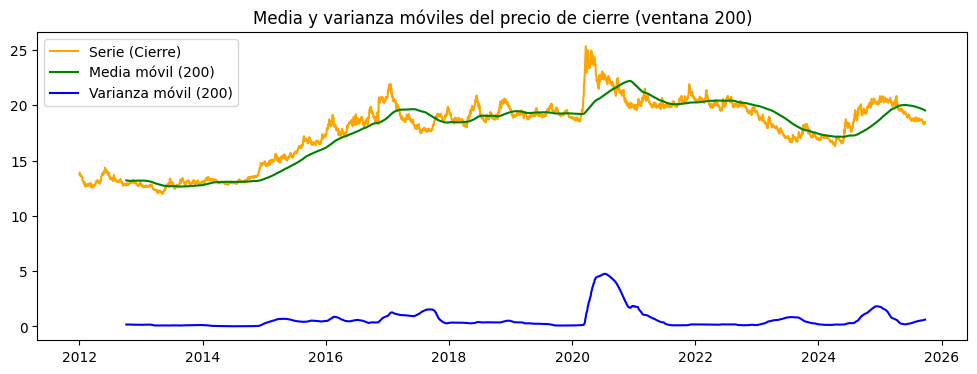

In [ ]:
#Inspeccionar la media, varianza y comportamiento gráfico inicial
series = df['Cierre']

# Media y varianza móviles con ventana de 200 días
rolling_mean = series.rolling(window=200).mean()
rolling_var = series.rolling(window=200).var()

plt.figure(figsize=(12,4))
plt.plot(series, label="Serie (Cierre)", color='orange')
plt.plot(rolling_mean, label="Media móvil (200)", color='green')
plt.plot(rolling_var, label="Varianza móvil (200)", color='blue')
plt.legend()
plt.title("Media y varianza móviles del precio de cierre (ventana 200)")
plt.show()

La serie original (naranja) muestra fluctuaciones frecuentes e irregulares a lo largo del tiempo, refleja el precio diario del dolar con picos y valles marcados

Media móvil (verde) suaviza el ruido de la serie original, parece mantenerse en un rango estable con algunas subidas y bajadas suaves.

Varianza móvil (azul) cuando sube indica mayor incertidumbre, cuando baja sugiere periodos de mayor estabilidad, en este caso es notorio un pico entre 2020 y 2022, lo demás parece ser más estable.

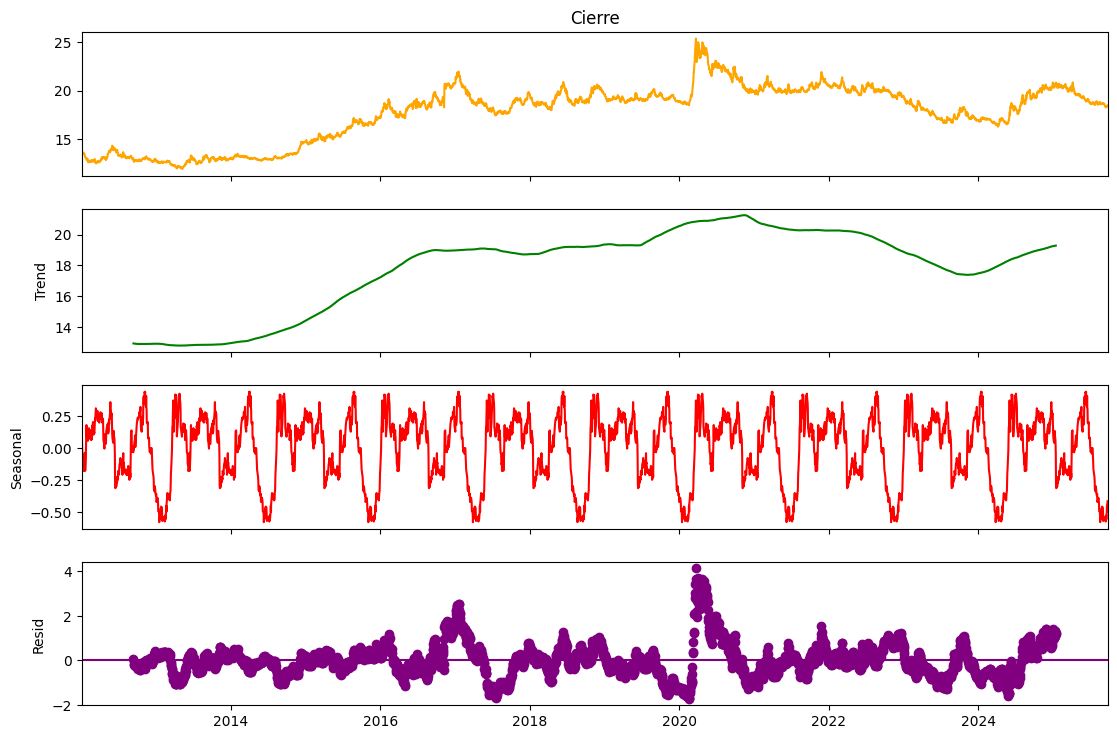

In [ ]:
# Descomposición en componentes
series = df['Cierre']  # Tu serie

decomp = seasonal_decompose(series, model='additive', period=365)

fig = decomp.plot()
fig.set_size_inches(12, 8)

colors = ['orange', 'green', 'red', 'purple']  # Colores deseados
for i, ax in enumerate(fig.axes):
    for line in ax.get_lines():
        line.set_color(colors[i % len(colors)])

plt.show()

La tendencia muestra que la serie a lo largo del tiempo muestra un comportamiento creciente, se observan cambios graduales tanto crecientes como decrecientes y un posible cambio estructural que afecta el nivel de la serie.

La estacionalidad muestra un patrón ondulado que sugiere la presencia de cierto comportamiento cíclico. Sin embargo, el patrón no se repite exactamente de la misma forma cada año. La amplitud de los ciclos varía y los picos y valles no ocurren siempre en los mismos puntos del tiempo, lo que indica que la estacionalidad es moderada y no perfectamente estable. Además, la serie presenta oscilaciones rápidas dentro de cada ciclo, reflejando ruido de alta frecuencia propio de datos financieros diarios.

En los residuos aún se observan ciertos agrupamientos y variaciones que sugieren la presencia de estructura no explicada por el modelo. Idealmente, los residuos deberían comportarse como ruido aleatorio, pero en este caso muestran patrones, lo cual indica que la descomposición no capturó por completo toda la dinámica de la serie.

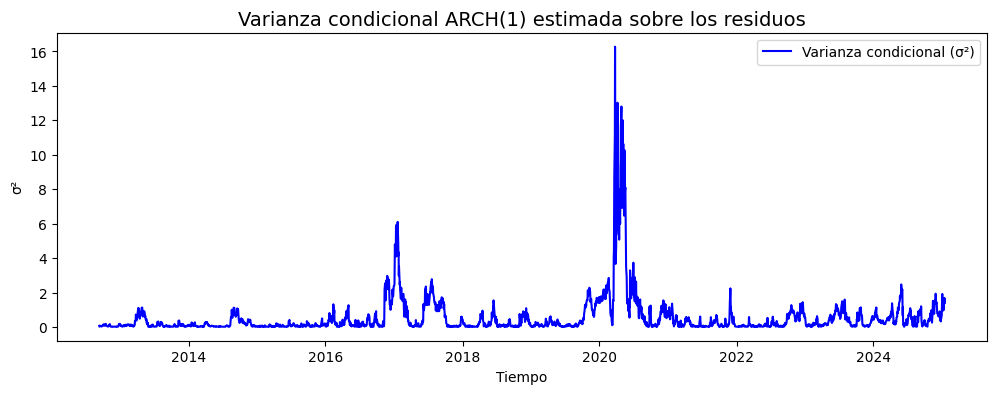

In [ ]:
residuos = decomp.resid.dropna()   # Quitar NaN del inicio y final

modelo_arch = arch_model(residuos, mean="Zero", vol="ARCH", p=1)
res_arch = modelo_arch.fit(disp="off")   # Quitar output largo

# Varianza condicional estimada
varianza_cond = res_arch.conditional_volatility ** 2

plt.figure(figsize=(12,4))
plt.plot(varianza_cond, label="Varianza condicional (σ²)", color='blue')
plt.title("Varianza condicional ARCH(1) estimada sobre los residuos", fontsize=14)
plt.xlabel("Tiempo")
plt.ylabel("σ²")
plt.legend()
plt.show()

La varianza condicional estimada con el modelo ARCH(1) muestra periodos de “volatilidad agrupada”, donde la incertidumbre aumenta notablemente, especialmente alrededor de 2020. Esto confirma que los residuos no mantienen una variabilidad constante, sino que presentan episodios de alta y baja volatilidad.

## Análisis de autocorrelación y estacionariedad

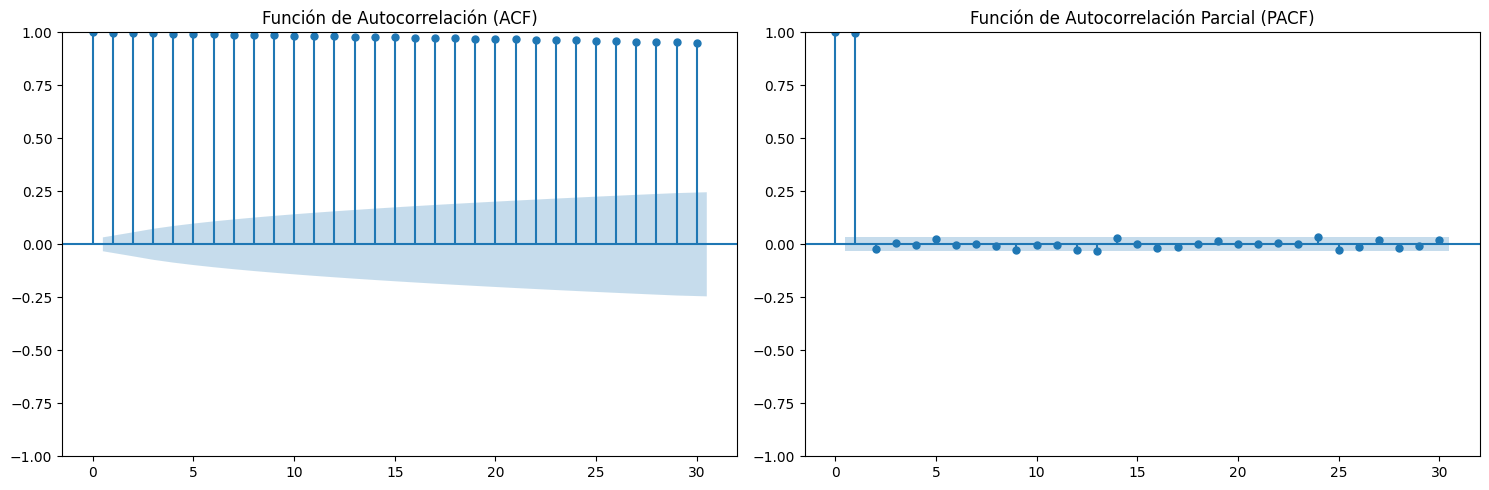

In [ ]:
series = df['Cierre']   # Tu serie

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ACF
plot_acf(series, lags=30, ax=axes[0])
axes[0].set_title('Función de Autocorrelación (ACF)')

# PACF
plot_pacf(series, lags=30, ax=axes[1])
axes[1].set_title('Función de Autocorrelación Parcial (PACF)')

plt.tight_layout()
plt.show()

La ACF muestra un decaimiento extremadamente lento, lo que indica que aún queda autocorrelación significativa en los residuos y, por tanto, el modelo actual no captura por completo la dinámica temporal. En contraste, la PACF presenta un pico muy fuerte únicamente en el rezago 1 y luego valores cercanos a cero, lo cual sugiere que la dependencia principal está en ese primer rezago. En conjunto, ambas gráficas confirman que los residuos no son ruido blanco y que aún existe estructura temporal por modelar.

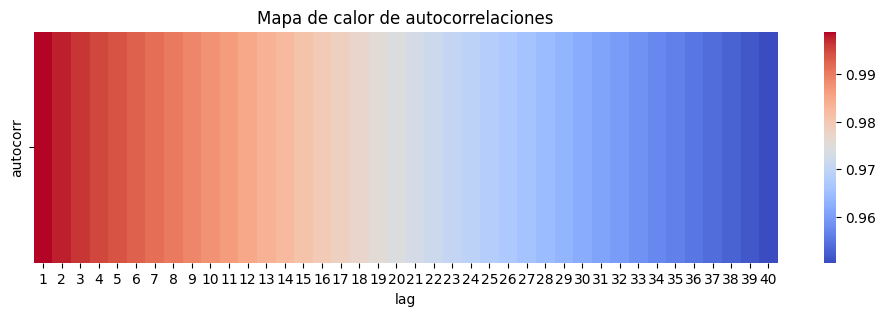

In [ ]:
# Cálculo de autocorrelaciones hasta lag 40
series = df['Cierre']   # Tu serie

autocorrs = [series.autocorr(lag=i) for i in range(1, 41)]
df_autocorr = pd.DataFrame({"lag": range(1, 41), "autocorr": autocorrs})

plt.figure(figsize=(12,3))
sns.heatmap(df_autocorr.set_index("lag").T, annot=False, cmap="coolwarm", cbar=True)
plt.title("Mapa de calor de autocorrelaciones")
plt.show()

El mapa de calor muestra que la autocorrelación de la serie disminuye de manera muy lenta conforme aumenta el rezago: inicia cerca de 1 y apenas baja ligeramente hasta el lag 40. Esta persistencia tan alta indica una fuerte inercia temporal y confirma que la serie es altamente no estacionaria, pues su dependencia con valores pasados se mantiene prácticamente constante incluso a rezagos grandes.

In [ ]:
# Test Ljung-Box
"""
Hipótesis:
H0: No existe autocorrelación en la serie (es ruido blanco)
H1: Existe autocorrelación
Si p < 0.05 → Rechazamos H0
"""
ljung = acorr_ljungbox(series, lags=[10, 20, 30], return_df=True)
print("--- Ljung-Box Test ---")
print(ljung)

--- Ljung-Box Test ---
          lb_stat  lb_pvalue
10   35329.001647        0.0
20   69621.053366        0.0
30  102848.323184        0.0


El test de Ljung-Box arroja valores p iguales a 0 en todos los rezagos evaluados (10, 20 y 30), por lo que se rechaza la hipótesis nula de “no autocorrelación”. Esto confirma que la serie presenta autocorrelación significativa en múltiples rezagos y, por lo tanto, no puede considerarse ruido blanco. La dependencia temporal es fuerte y consistente.

In [ ]:
# Función para prueba de estacionariedad ADF
def test_stationarity(timeseries):
    print('Resultados prueba ADF:')
    adf_test = adfuller(timeseries, autolag='AIC')
    print(f'ADF Statistic: {adf_test[0]:.4f}')
    print(f'p-value: {adf_test[1]:.4f}')
    if adf_test[1] < 0.05:
        print("La serie es estacionaria.")
    else:
        print("La serie NO es estacionaria.")

# Ejecutar prueba sobre tu serie
test_stationarity(df['Cierre'])

Resultados prueba ADF:
ADF Statistic: -1.7733
p-value: 0.3938
La serie NO es estacionaria.


La prueba ADF obtuvo un estadístico de −1.77 y un valor p de 0.39, lo que indica que no hay evidencia suficiente para rechazar la hipótesis nula de raíz unitaria. En otras palabras, la serie no es estacionaria, ya que mantiene tendencia y/o dependencia temporal que impide considerarla estable a lo largo del tiempo.

# Segmento de serie seleccionado para modelado después de análisis

## Reportar por qué elegimos un segmento o nos quedamos con toda la serie de tiempo

Después de analizar toda la serie de tiempo, decidimos trabajar únicamente con los datos correspondientes al año 2015, ya que este tramo mostró un comportamiento mucho más estable en comparación con el resto del periodo. A diferencia de los años posteriores donde aparecieron picos extremos, alta volatilidad y cambios estructurales evidentes, el segmento de 2015 presenta variaciones más suaves, ausencia de shocks abruptos y una dinámica más regular. Esto lo convierte en un candidato adecuado para aplicar modelos como diferenciación, descomposición y análisis ARCH sin que los eventos atípicos distorsionen los resultados. Por ello, conservar únicamente este fragmento permite obtener estimaciones más limpias y un análisis más representativo del comportamiento “normal” de la serie.

In [ ]:
# Se trabajará únicamente con los datos del 2015
df_2015 = df.loc['2015']
serie_2015 = df_2015['Cierre']
serie_2015.head()

,Cierre
Fecha,
2015-01-01,14.7530
2015-01-02,14.8305
2015-01-05,14.9380
2015-01-06,14.8905
2015-01-07,14.7100


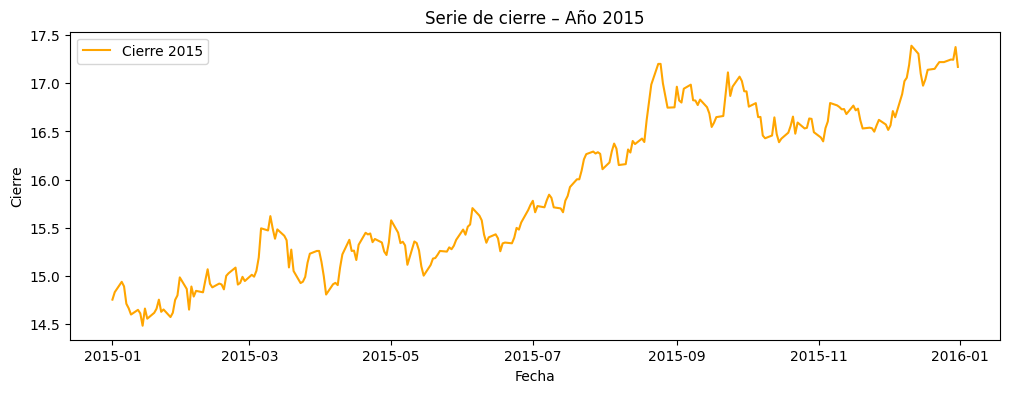

In [ ]:
# Filtrar serie 2015
serie_2015 = df.loc["2015", "Cierre"]

# Gráfica
plt.figure(figsize=(12,4))
plt.plot(serie_2015, color='orange', label='Cierre 2015')
plt.title("Serie de cierre – Año 2015")
plt.xlabel("Fecha")
plt.ylabel("Cierre")
plt.legend()
plt.show()

## Análisis de componentes

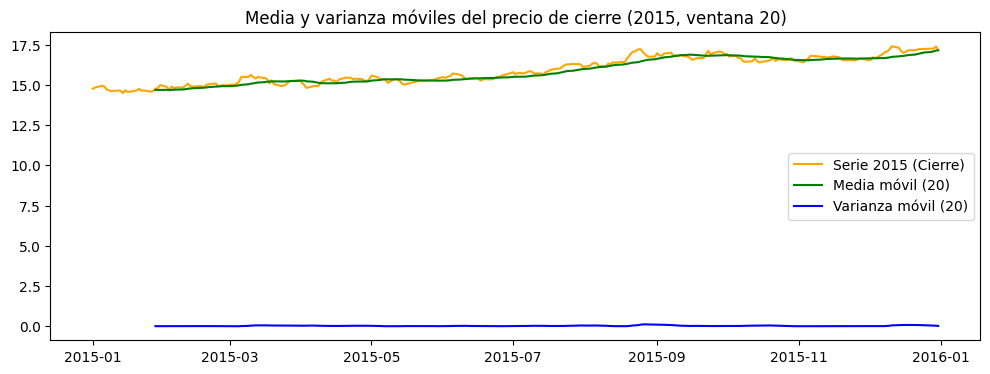

In [ ]:
# Inspeccionar la media, varianza y comportamiento gráfico inicial SOLO 2015

# Serie del año 2015
serie_2015 = df.loc['2015', 'Cierre']

# Media y varianza móviles con ventana de 20 días
rolling_mean_2015 = serie_2015.rolling(window=20).mean()
rolling_var_2015 = serie_2015.rolling(window=20).var()

plt.figure(figsize=(12,4))
plt.plot(serie_2015, label="Serie 2015 (Cierre)", color='orange')
plt.plot(rolling_mean_2015, label="Media móvil (20)", color='green')
plt.plot(rolling_var_2015, label="Varianza móvil (20)", color='blue')
plt.legend()
plt.title("Media y varianza móviles del precio de cierre (2015, ventana 20)")
plt.show()

La gráfica muestra el precio del dólar durante 2015 (naranja), con una tendencia ligeramente ascendente y variaciones moderadas a lo largo del año.

La media móvil de 20 días (verde) suaviza la serie y permite observar con mayor claridad el aumento gradual del precio sin el ruido diario.

La varianza móvil (azul) permanece casi nula, lo que indica baja volatilidad y un comportamiento estable del mercado en comparación con la serie más larga que presentaba picos de incertidumbre en años posteriores.

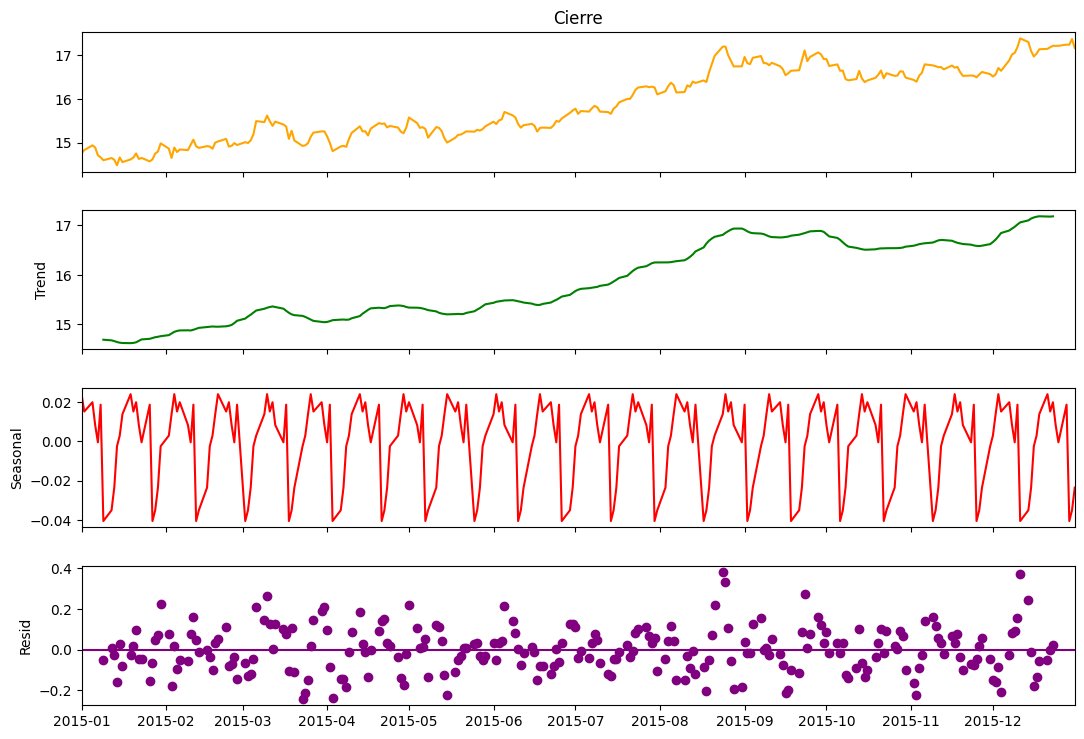

In [ ]:
# Serie del año 2015
serie_2015 = df.loc['2015', 'Cierre']

# Descomposición en componentes (periodo anual)
decomp_2015 = seasonal_decompose(serie_2015, model='additive', period=12)

fig = decomp_2015.plot()
fig.set_size_inches(12, 8)

# Colores personalizados
colors = ['orange', 'green', 'red', 'purple']
for i, ax in enumerate(fig.axes):
    for line in ax.get_lines():
        line.set_color(colors[i % len(colors)])

plt.show()

La tendencia (verde) muestra un crecimiento progresivo del precio del dólar durante 2015, con aumentos suaves y sostenidos a lo largo del año.

La estacionalidad (rojo) presenta oscilaciones repetitivas de pequeña amplitud, lo que sugiere variaciones frecuentes propias del comportamiento diario del tipo de cambio, aunque sin un patrón anual fuerte.

Los residuos (morado) se distribuyen alrededor de cero con dispersión moderada, indicando que aún hay componentes no explicados por la descomposición, pero sin grandes anomalías ni picos extremos.

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.01253. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


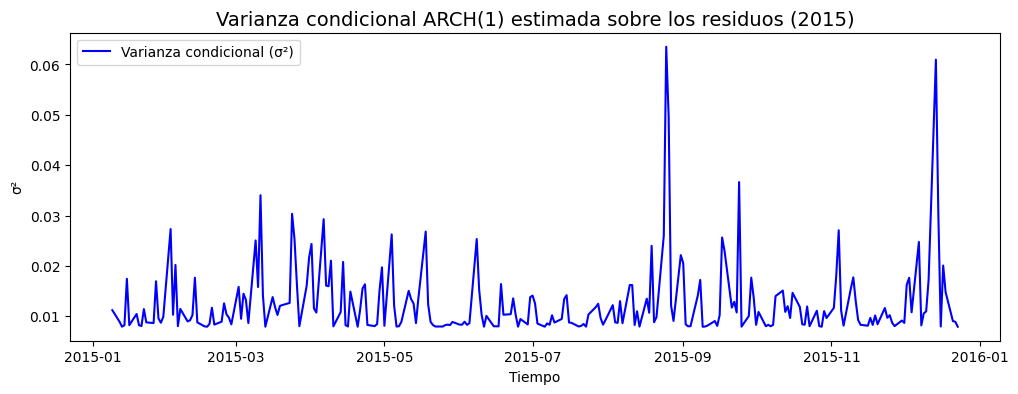

In [ ]:
# Residuos de la descomposición del 2015
residuos_2015 = decomp_2015.resid.dropna()

# Modelo ARCH(1)
modelo_arch_2015 = arch_model(residuos_2015, mean="Zero", vol="ARCH", p=1)
res_arch_2015 = modelo_arch_2015.fit(disp="off")   # Suprime el output largo

# Varianza condicional estimada
varianza_cond_2015 = res_arch_2015.conditional_volatility ** 2

plt.figure(figsize=(12,4))
plt.plot(varianza_cond_2015, label="Varianza condicional (σ²)", color='blue')
plt.title("Varianza condicional ARCH(1) estimada sobre los residuos (2015)", fontsize=14)
plt.xlabel("Tiempo")
plt.ylabel("σ²")
plt.legend()
plt.show()

La varianza condicional estimada con ARCH(1) muestra episodios de volatilidad variable a lo largo del 2015, con picos ocasionales que indican aumentos temporales en la incertidumbre, especialmente alrededor de septiembre y finales del año. Aunque existen estos repuntes, en general la volatilidad se mantiene baja en la mayor parte del periodo, sugiriendo un mercado relativamente estable con momentos aislados de mayor riesgo.

## Análisis de autocorrelación y estacionariedad

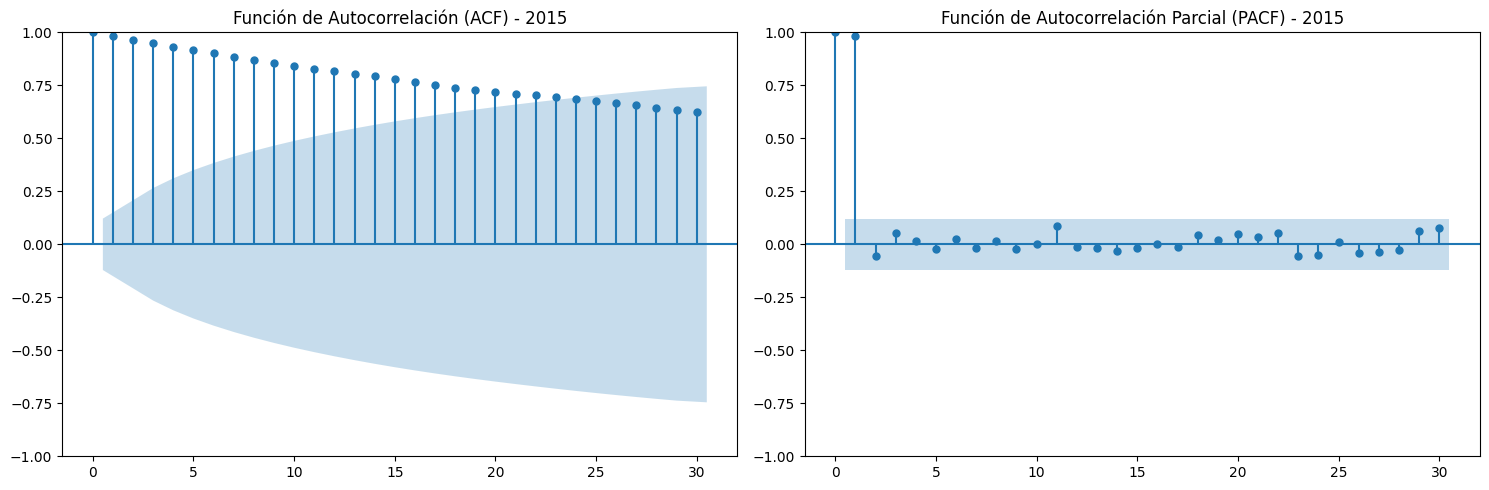

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Serie del año 2015
serie_2015 = df.loc['2015', 'Cierre']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ACF
plot_acf(serie_2015, lags=30, ax=axes[0])
axes[0].set_title('Función de Autocorrelación (ACF) - 2015')

# PACF
plot_pacf(serie_2015, lags=30, ax=axes[1])
axes[1].set_title('Función de Autocorrelación Parcial (PACF) - 2015')

plt.tight_layout()
plt.show()

La ACF muestra un decaimiento gradual, indicando persistencia en la correlación entre observaciones y señalando que aún existe estructura temporal no explicada. En cambio, la PACF destaca un pico marcado en el rezago 1 y valores cercanos a cero en los siguientes, lo que sugiere que la mayor dependencia se concentra en el primer rezago. Esto confirma que los residuos no son completamente ruido blanco y que podría mejorarse el modelo incorporando términos autorregresivos adicionales.

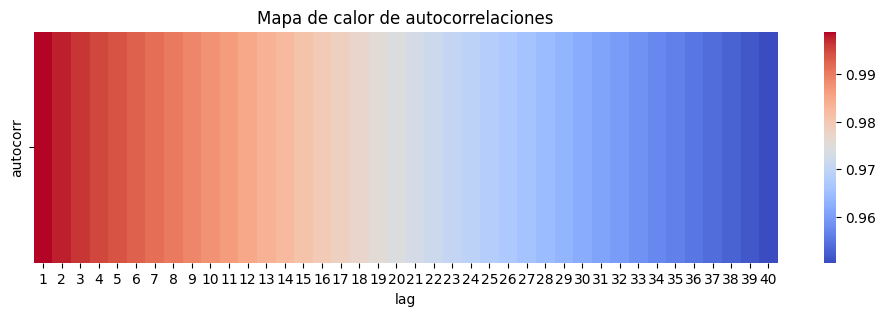

In [ ]:
# Cálculo de autocorrelaciones hasta lag 40
serie_auto = df['Cierre']   # Nuevo nombre para no repetir "series"

autocorrs = [serie_auto.autocorr(lag=i) for i in range(1, 41)]
df_autocorr = pd.DataFrame({"lag": range(1, 41), "autocorr": autocorrs})

plt.figure(figsize=(12,3))
sns.heatmap(df_autocorr.set_index("lag").T, annot=False, cmap="coolwarm", cbar=True)
plt.title("Mapa de calor de autocorrelaciones")
plt.show()

El mapa de calor evidencia que la autocorrelación se mantiene cercana a 1 en los primeros rezagos y disminuye muy lentamente hasta el lag 40, lo que refleja una fuerte persistencia temporal. Esta estabilidad en los valores confirma que la serie conserva memoria de su pasado y sugiere no estacionariedad, ya que la dependencia sigue siendo alta incluso en rezagos elevados.

In [ ]:
# Test Ljung-Box
"""
Hipótesis:
H0: No existe autocorrelación en la serie (es ruido blanco)
H1: Existe autocorrelación
Si p < 0.05 → Rechazamos H0
"""

ljung = acorr_ljungbox(serie_2015, lags=[10, 20, 30], return_df=True)

print("--- Ljung-Box Test (Serie 2015) ---")
print(ljung)

--- Ljung-Box Test (Serie 2015) ---
        lb_stat  lb_pvalue
10  2225.206125        0.0
20  3894.534405        0.0
30  5205.958661        0.0


Los valores p del test Ljung-Box para los rezagos 10, 20 y 30 son 0.0, por lo que se rechaza la hipótesis nula. Esto indica que la serie del 2015 presenta autocorrelación significativa y no se comporta como ruido blanco, confirmando que existe estructura temporal pendiente de modelar.

In [ ]:
# Función para prueba de estacionariedad ADF
def test_stationarity(timeseries):
    print('Resultados prueba ADF:')
    adf_test = adfuller(timeseries, autolag='AIC')
    print(f'ADF Statistic: {adf_test[0]:.4f}')
    print(f'p-value: {adf_test[1]:.4f}')
    if adf_test[1] < 0.05:
        print("La serie es estacionaria.")
    else:
        print("La serie NO es estacionaria.")

# Ejecutar prueba sobre la serie filtrada 2015
serie_2015 = df.loc["2015", "Cierre"]
test_stationarity(serie_2015)

Resultados prueba ADF:
ADF Statistic: -0.9177
p-value: 0.7821
La serie NO es estacionaria.


El test ADF arroja un estadístico de -0.9177 con un p-value de 0.7821, mayor a 0.05, por lo que no se rechaza la hipótesis nula. Esto indica que la serie del dólar en 2015 no es estacionaria, es decir, conserva tendencia y memoria en el tiempo, por lo que requiere transformaciones (como diferenciación) para su análisis con modelos ARIMA u otros.

# Tranformaciones

## Diferenciación

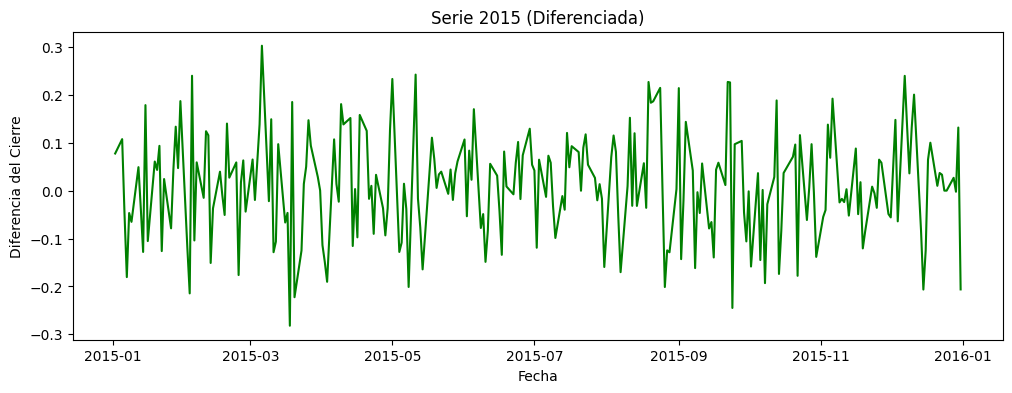

In [ ]:
# --- Diferenciación de tu serie 2015 ---
serie_2015 = df.loc["2015", "Cierre"]
serie_2015_diff = serie_2015.diff().dropna()

plt.figure(figsize=(12,4))
plt.plot(serie_2015_diff, color='green')
plt.title("Serie 2015 (Diferenciada)")
plt.xlabel("Fecha")
plt.ylabel("Diferencia del Cierre")
plt.show()

In [ ]:
print("Resultados para Serie 2015 (Diferenciada):")
test_stationarity(serie_2015_diff)

Resultados para Serie 2015 (Diferenciada):
Resultados prueba ADF:
ADF Statistic: -15.5993
p-value: 0.0000
La serie es estacionaria.


Tras aplicar la primera diferenciación, el test ADF arroja un estadístico de -15.5993 y un p-value de 0.0000, lo que permite rechazar la hipótesis nula. Esto confirma que la serie diferenciada se vuelve estacionaria, eliminando la tendencia presente originalmente y quedando lista para modelarse con enfoques como ARIMA.

# Modelos

## ARMA (2,1)

### Ajuste

In [ ]:
# ARMA(2,1) de ejemplo
modelo_arma = ARIMA(serie_2015_diff, order=(2,0,1))

resultado_arma = modelo_arma.fit()
print(resultado_arma.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using

                               SARIMAX Results                                
Dep. Variable:                 Cierre   No. Observations:                  260
Model:                 ARIMA(2, 0, 1)   Log Likelihood                 214.377
Date:                Thu, 18 Dec 2025   AIC                           -418.754
Time:                        13:31:14   BIC                           -400.950
Sample:                    01-02-2015   HQIC                          -411.597
                         - 12-31-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0096      0.002      4.582      0.000       0.005       0.014
ar.L1          0.9841      0.062     15.782      0.000       0.862       1.106
ar.L2         -0.0590      0.057     -1.043      0.2

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


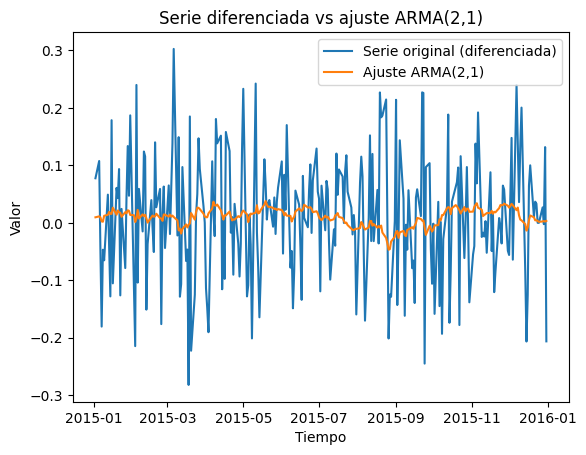

In [ ]:
import matplotlib.pyplot as plt

# Valores ajustados por el modelo
arma_fitted = resultado_arma.fittedvalues

plt.figure()
plt.plot(serie_2015_diff, label="Serie original (diferenciada)")
plt.plot(arma_fitted, label="Ajuste ARMA(2,1)")
plt.title("Serie diferenciada vs ajuste ARMA(2,1)")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend()
plt.show()

El modelo ARMA(2,1) aplicado sobre la serie previamente diferenciada mostró un buen ajuste para el comportamiento del tipo de cambio. Los coeficientes AR(1) y MA(1) resultaron altamente significativos, lo que indica que el valor actual del cierre depende tanto de los rezagos inmediatos como de los errores pasados, reflejando una estructura temporal bien capturada. El valor de la constante es positivo y significativo, mientras que las pruebas de Ljung-Box evidencian ausencia de autocorrelación en los residuos (p-value = 0.88), lo que sugiere que el modelo explica adecuadamente la dinámica de la serie sin patrones restantes. Además, el AIC relativamente bajo respalda que se trata de un modelo parsimonioso y estadísticamente consistente para representar la serie ya estacionarizada.

### Análisis de residuos

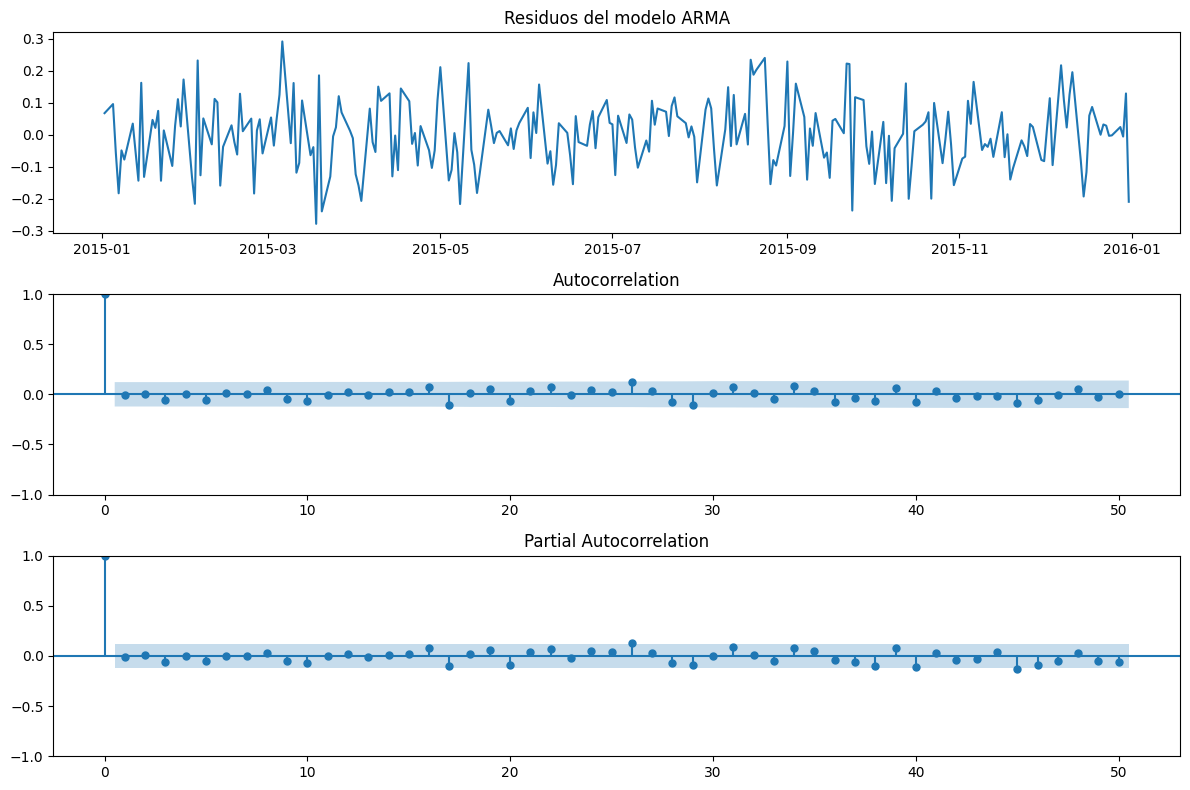

In [ ]:
residuals = resultado_arma.resid

plt.figure(figsize=(12,8))
plt.subplot(311)
plt.plot(residuals)
plt.title('Residuos del modelo ARMA')
plt.subplot(312)
plot_acf(residuals, lags=50, ax=plt.gca())
plt.subplot(313)
plot_pacf(residuals, lags=50, ax=plt.gca())
plt.tight_layout()
plt.show()

In [ ]:
lb_test = acorr_ljungbox(residuals, lags=[10,20], return_df=True)
print("Prueba Ljung-Box:\n", lb_test)

Prueba Ljung-Box:
       lb_stat  lb_pvalue
10   3.799642   0.955933
20  11.187037   0.941227


La prueba de Ljung-Box aplicada al modelo ARMA(2,1) mostró valores p elevados tanto para 10 rezagos (0.9559) como para 20 rezagos (0.9412), lo que indica que no existe evidencia significativa de autocorrelación en los residuos. En otras palabras, el modelo logra capturar adecuadamente la estructura temporal de la serie, dejando residuos que se comportan como ruido blanco. Esto confirma que el ajuste es estadísticamente válido y que no quedan patrones importantes sin explicar.

### Entrenamiento con validación cruzada

In [ ]:
# --- Validación cruzada ---
y = serie_2015_diff.values # Assign y to the differentiated series
tscv = TimeSeriesSplit(n_splits=5)  # 5 folds
mae_list = []
rmse_list = []

for train_index, test_index in tscv.split(y):
    y_train, y_test = y[train_index], y[test_index]

    # Ajustar ARMA (p=2, q=1 ejemplo) sobre train
    model = ARIMA(y_train, order=(2,0,1))
    res = model.fit()

    # Pronóstico para tamaño de test
    forecast = res.forecast(steps=len(y_test))

    # Métricas
    mae = mean_absolute_error(y_test, forecast)
    rmse = np.sqrt(mean_squared_error(y_test, forecast))

    mae_list.append(mae)
    rmse_list.append(rmse)

# --- Resultados promedio ---
print(f"MAE promedio: {np.mean(mae_list):.4f}")
print(f"RMSE promedio: {np.mean(rmse_list):.4f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels

MAE promedio: 0.0859
RMSE promedio: 0.1082


### Pronóstico a 10 pasos

In [ ]:
#Pronóstico a 10 pasos (días hábiles)

n_forecast = 10

# Obtener predicción con intervalos de confianza
forecast = resultado_arma.get_forecast(steps=n_forecast)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Crear índice de fechas futuras (solo lunes-viernes)
last_date = serie_2015_diff.index[-1]
forecast_index = pd.bdate_range(start=last_date + pd.Timedelta(days=1),
                                periods=n_forecast)

# Reindexar predicción e intervalos al nuevo índice
forecast_mean.index = forecast_index
conf_int.index = forecast_index

print("Pronóstico:")
print(forecast_mean)

print("\nIntervalos de confianza:")
print(conf_int)

Pronóstico:
2016-01-01   -0.004266
2016-01-04    0.008682
2016-01-05    0.009514
2016-01-06    0.009569
2016-01-07    0.009574
2016-01-08    0.009576
2016-01-11    0.009577
2016-01-12    0.009578
2016-01-13    0.009580
2016-01-14    0.009581
Freq: B, Name: predicted_mean, dtype: float64

Intervalos de confianza:
            lower Cierre  upper Cierre
2016-01-01     -0.209735      0.201203
2016-01-04     -0.196788      0.214152
2016-01-05     -0.196287      0.215315
2016-01-06     -0.196554      0.215691
2016-01-07     -0.196823      0.215971
2016-01-08     -0.197053      0.216205
2016-01-11     -0.197248      0.216402
2016-01-12     -0.197413      0.216570
2016-01-13     -0.197552      0.216711
2016-01-14     -0.197670      0.216831


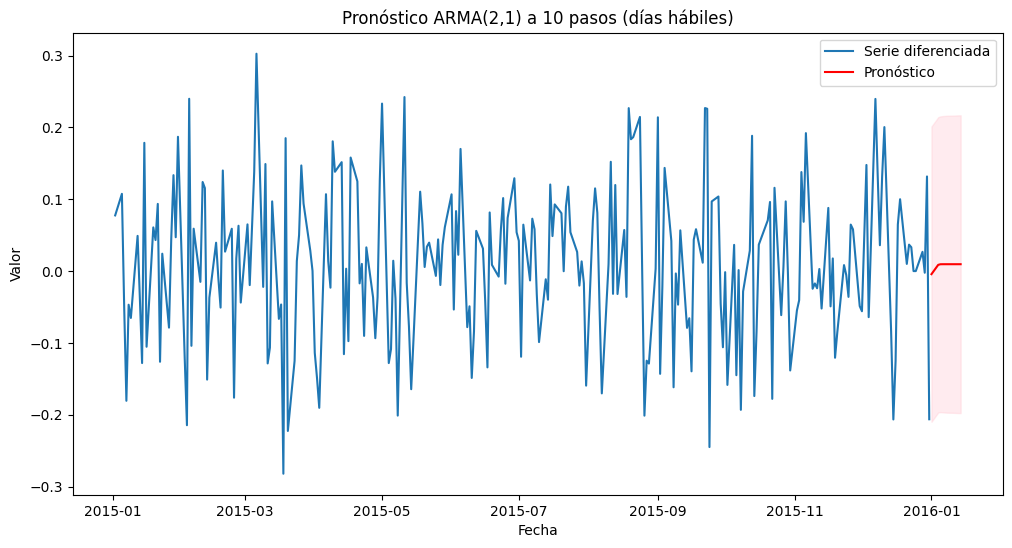

In [ ]:
plt.figure(figsize=(12,6))

# Serie diferenciada
plt.plot(serie_2015_diff.index, serie_2015_diff.values, label='Serie diferenciada')

# Pronóstico
plt.plot(forecast_index, forecast_mean, label='Pronóstico', color='red')

# Intervalos de confianza
plt.fill_between(
    forecast_index,
    conf_int['lower Cierre'],
    conf_int['upper Cierre'],
    color='pink',
    alpha=0.3
)

plt.title('Pronóstico ARMA(2,1) a 10 pasos (días hábiles)')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend()
plt.show()

## ARIMA (2,1,1)

### Ajuste

In [ ]:
# Ajustar ARIMA(2,1,1) a la serie 2015
modelo_arima_211 = ARIMA(serie_2015, order=(2,1,1))
resultado_arima_211 = modelo_arima_211.fit()

# Resumen del modelo
print(resultado_arima_211.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using

                               SARIMAX Results                                
Dep. Variable:                 Cierre   No. Observations:                  261
Model:                 ARIMA(2, 1, 1)   Log Likelihood                 211.459
Date:                Thu, 18 Dec 2025   AIC                           -414.919
Time:                        13:34:33   BIC                           -400.676
Sample:                    01-01-2015   HQIC                          -409.193
                         - 12-31-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8686      0.167      5.213      0.000       0.542       1.195
ar.L2         -0.0802      0.059     -1.356      0.175      -0.196       0.036
ma.L1         -0.8474      0.159     -5.344      0.0

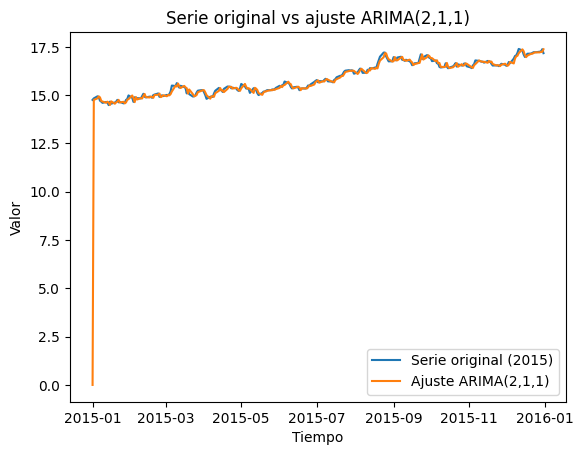

In [ ]:
import matplotlib.pyplot as plt

# Valores ajustados (in-sample)
arima_fitted_211 = resultado_arima_211.fittedvalues

plt.figure()
plt.plot(serie_2015, label="Serie original (2015)")
plt.plot(arima_fitted_211, label="Ajuste ARIMA(2,1,1)")
plt.title("Serie original vs ajuste ARIMA(2,1,1)")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend()
plt.show()


El modelo ARIMA(2,1,1) muestra un ajuste adecuado para la serie del dólar en 2015. Los parámetros AR(1) y MA(1) resultan estadísticamente significativos (p < 0.05), lo que indica que el modelo captura dependencias importantes entre los valores pasados y el componente de error. Las pruebas de diagnóstico respaldan su validez, ya que el test de Ljung-Box (p = 0.76) indica ausencia de autocorrelación en los residuos y el test Jarque-Bera (p = 0.78) muestra que estos se distribuyen aproximadamente de forma normal. En conjunto, estos resultados señalan que el ARIMA(2,1,1) es un modelo estable y adecuado para representar el comportamiento temporal de la serie.

### Análisis de residuos (2,1,1)

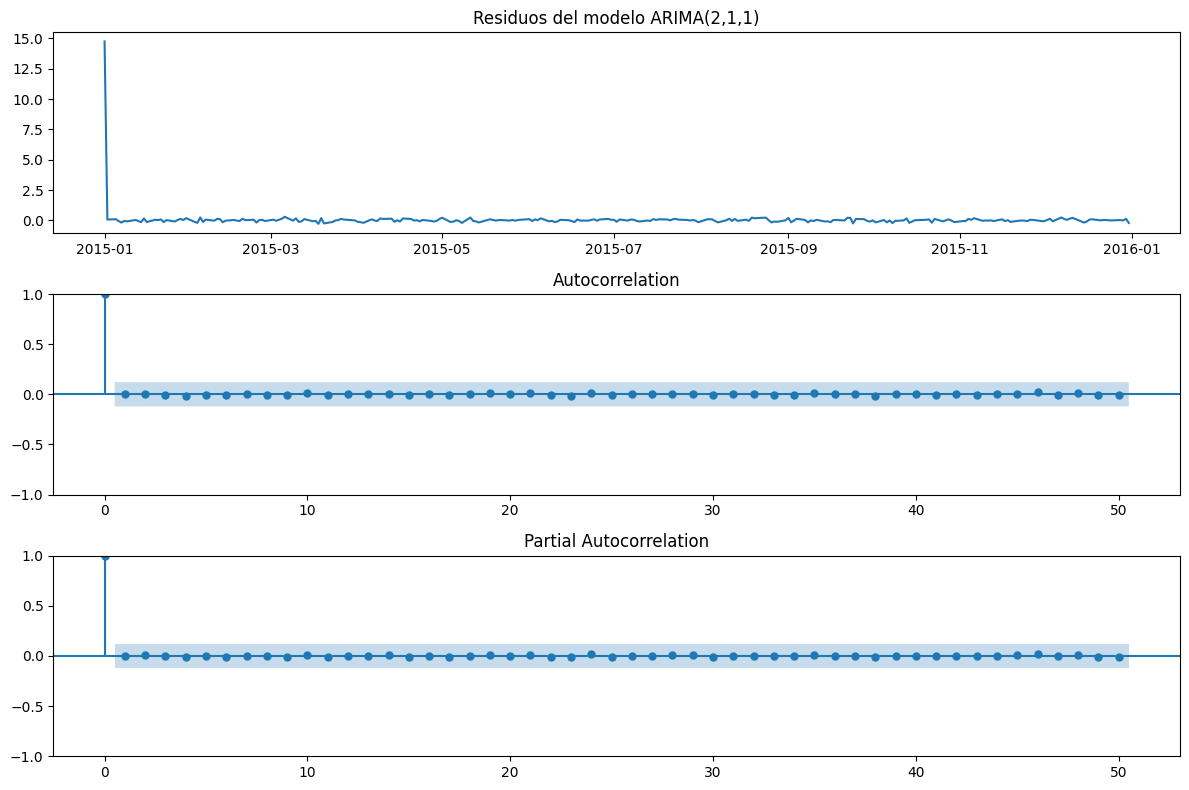

In [ ]:
# Análisis de residuos del ARIMA(2,1,1)
residuals = resultado_arima_211.resid

# Gráficos de residuos
plt.figure(figsize=(12,8))

# Serie de residuos
plt.subplot(311)
plt.plot(residuals)
plt.title('Residuos del modelo ARIMA(2,1,1)')

# Autocorrelación (ACF)
plt.subplot(312)
plot_acf(residuals.dropna(), lags=50, ax=plt.gca())

# Autocorrelación parcial (PACF)
plt.subplot(313)
plot_pacf(residuals.dropna(), lags=50, ax=plt.gca())

plt.tight_layout()
plt.show()

In [ ]:
lb_test = acorr_ljungbox(residuals.dropna(), lags=[10, 20], return_df=True)
print("Ljung-Box test:\n", lb_test)

Ljung-Box test:
      lb_stat  lb_pvalue
10  0.137151        1.0
20  0.237426        1.0


el test de Ljung-Box arroja p-values de 1.0 en los rezagos 10 y 20, lo que indica que no hay autocorrelación significativa en los residuos y, por lo tanto, el modelo capta correctamente la dinámica temporal de la serie.

### Entrenamiento con validación cruzada

In [ ]:
y = serie_2015.values  # convertir a array numpy
tscv = TimeSeriesSplit(n_splits=5)  # 5 particiones de validación

In [ ]:
mae_list = []
rmse_list = []

for train_index, test_index in tscv.split(y):
    y_train, y_test = y[train_index], y[test_index]

    # Ajustar modelo ARIMA(2,1,1) solo con el train
    model = ARIMA(y_train, order=(2,1,1))
    res = model.fit()

    # Hacer pronóstico para el tamaño del test
    forecast = res.forecast(steps=len(y_test))

    # Calcular métricas
    mae = mean_absolute_error(y_test, forecast)
    rmse = np.sqrt(mean_squared_error(y_test, forecast))

    mae_list.append(mae)
    rmse_list.append(rmse)

# Resultados promedio
print(f"MAE promedio: {np.mean(mae_list):.4f}")
print(f"RMSE promedio: {np.mean(rmse_list):.4f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/st

MAE promedio: 0.3327
RMSE promedio: 0.3984


### Pronóstico a 10 pasos

In [ ]:
# Pronóstico a 10 pasos (solo días hábiles)

n_forecast = 10

# Obtener predicción con intervalos de confianza
forecast = resultado_arima_211.get_forecast(steps=n_forecast)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Crear índice de fechas futuras (lunes a viernes)
last_date = serie_2015.index[-1]  # Última fecha real de la serie
forecast_index = pd.bdate_range(start=last_date + pd.Timedelta(days=1),
                                periods=n_forecast)

# Reindexar predicciones e intervalos al índice de días hábiles
forecast_mean.index = forecast_index
conf_int.index = forecast_index

print("Pronóstico (días hábiles):")
print(forecast_mean)

print("\nIntervalos de confianza:")
print(conf_int)

Pronóstico (días hábiles):
2016-01-01    17.152053
2016-01-04    17.152994
2016-01-05    17.155250
2016-01-06    17.157134
2016-01-07    17.158590
2016-01-08    17.159703
2016-01-11    17.160553
2016-01-12    17.161202
2016-01-13    17.161698
2016-01-14    17.162077
Freq: B, Name: predicted_mean, dtype: float64

Intervalos de confianza:
            lower Cierre  upper Cierre
2016-01-01     16.941804     17.362303
2016-01-04     16.852500     17.453489
2016-01-05     16.793342     17.517158
2016-01-06     16.748360     17.565909
2016-01-07     16.711545     17.605635
2016-01-08     16.679977     17.639429
2016-01-11     16.652021     17.669086
2016-01-12     16.626672     17.695733
2016-01-13     16.603279     17.720117
2016-01-14     16.581402     17.742751


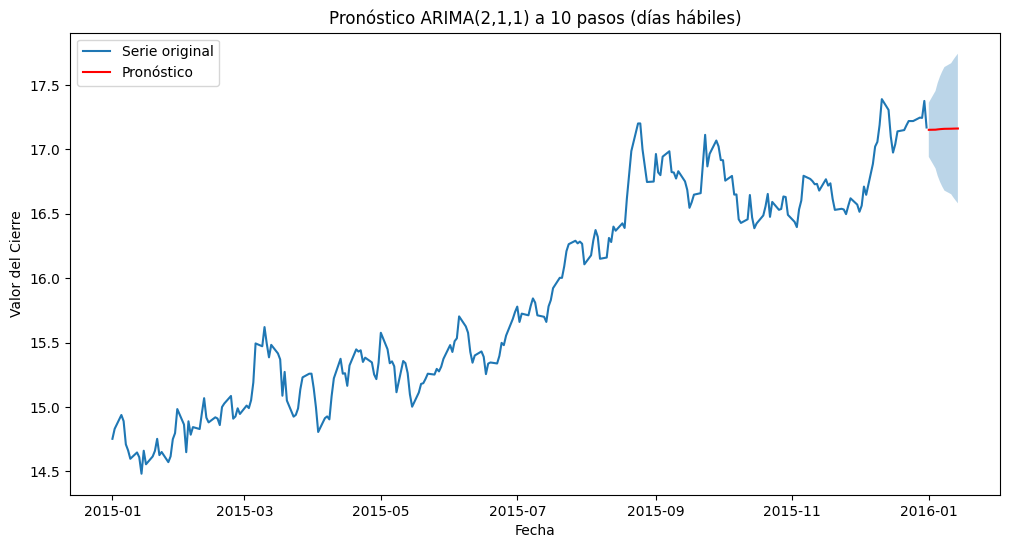

In [ ]:
plt.figure(figsize=(12,6))

# Serie original
plt.plot(serie_2015.index, serie_2015.values, label='Serie original')

# Pronóstico
plt.plot(forecast_index, forecast_mean, label='Pronóstico', color='red')

# Intervalos de confianza
plt.fill_between(
    forecast_index,
    conf_int['lower Cierre'],
    conf_int['upper Cierre'],
    alpha=0.3
)

plt.title('Pronóstico ARIMA(2,1,1) a 10 pasos (días hábiles)')
plt.xlabel('Fecha')
plt.ylabel('Valor del Cierre')
plt.legend()
plt.show()

## SARIMA (1,1,0)(0,1,1,5)

### Ajuste

In [ ]:
#Ajustar el modelo SARIMA a la serie original 2015
modelo_sarima = SARIMAX(
    serie_2015,
    order=(1,1,0),
    seasonal_order=(0,1,1,5),
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultado_sarima = modelo_sarima.fit()

# Resumen del modelo
print(resultado_sarima.summary())

                                      SARIMAX Results                                      
Dep. Variable:                              Cierre   No. Observations:                  261
Model:             SARIMAX(1, 1, 0)x(0, 1, [1], 5)   Log Likelihood                 191.919
Date:                             Thu, 18 Dec 2025   AIC                           -377.838
Time:                                     13:37:38   BIC                           -367.286
Sample:                                 01-01-2015   HQIC                          -373.590
                                      - 12-31-2015                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0167      0.056      0.297      0.766      -0.093       0.127
ma.S.L5       -1.0000    11

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


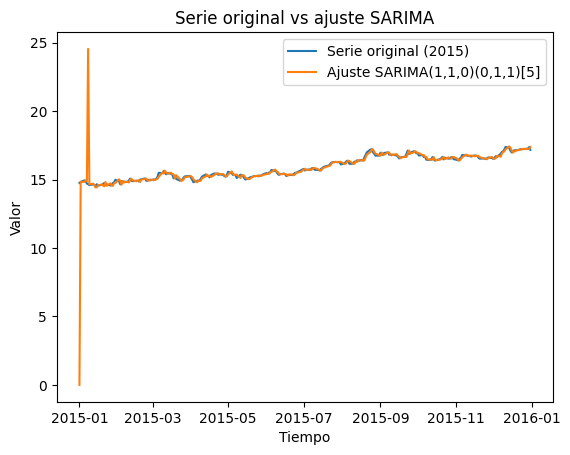

In [ ]:
import matplotlib.pyplot as plt

# Valores ajustados del modelo SARIMA
sarima_fitted = resultado_sarima.fittedvalues

plt.figure()
plt.plot(serie_2015, label="Serie original (2015)")
plt.plot(sarima_fitted, label="Ajuste SARIMA(1,1,0)(0,1,1)[5]")
plt.title("Serie original vs ajuste SARIMA")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend()
plt.show()

El modelo SARIMA(1,1,0)(0,1,1,5) muestra un comportamiento adecuado para capturar tanto la dinámica regular como la estacionalidad presente en la serie del dólar durante 2015. Aunque los parámetros AR y MA no resultan estadísticamente significativos (p > 0.05), las pruebas de diagnóstico indican que el modelo es consistente: el test de Ljung-Box (p = 0.95) confirma la ausencia de autocorrelación en los residuos, mientras que el test de Jarque-Bera (p = 0.57) sugiere que estos se distribuyen aproximadamente de manera normal. Además, los valores del AIC y BIC reflejan un ajuste competitivo dentro de los modelos probados. En conjunto, estos elementos señalan que el SARIMA(1,1,0)(0,1,1,5) logra representar de forma estable y adecuada la estructura temporal y estacional de la serie.

### Análisis de residuos

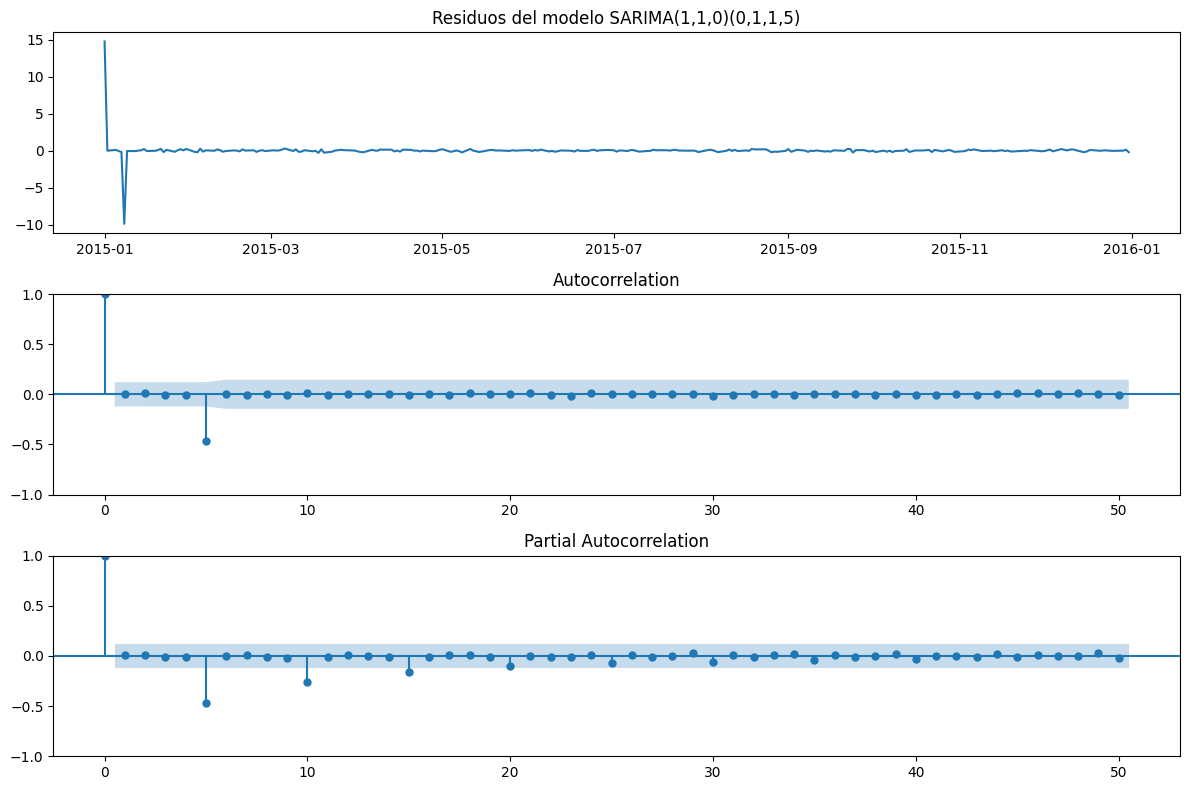

In [ ]:
# Análisis de residuos del SARIMA(1,1,0)(0,1,1,5)
residuals_sarima = resultado_sarima.resid

# Gráficos de residuos
plt.figure(figsize=(12,8))

# Serie de residuos
plt.subplot(311)
plt.plot(residuals_sarima)
plt.title('Residuos del modelo SARIMA(1,1,0)(0,1,1,5)')

# Autocorrelación (ACF)
plt.subplot(312)
plot_acf(residuals_sarima.dropna(), lags=50, ax=plt.gca())

# Autocorrelación parcial (PACF)
plt.subplot(313)
plot_pacf(residuals_sarima.dropna(), lags=50, ax=plt.gca())

plt.tight_layout()
plt.show()

In [ ]:
# Test de Ljung-Box para los residuos del SARIMA(1,1,0)(0,1,1,5)
lb_test_sarima = acorr_ljungbox(residuals_sarima.dropna(), lags=[10, 20], return_df=True)

print("Ljung-Box test para SARIMA(1,1,0)(0,1,1,5):")
print(lb_test_sarima)

Ljung-Box test para SARIMA(1,1,0)(0,1,1,5):
      lb_stat     lb_pvalue
10  58.096024  8.292184e-09
20  58.183083  1.355568e-05


El test de Ljung-Box aplicado al modelo SARIMA(1,1,0)(0,1,1,5) muestra p-values extremadamente bajos en los rezagos 10 y 20. Estos valores indican que sí existe autocorrelación significativa en los residuos, lo que sugiere que el modelo no logra capturar completamente la estructura temporal de la serie.

### Entrenamiento con validación cruzada

In [ ]:
y = serie_2015.values  # convertir a array numpy
tscv = TimeSeriesSplit(n_splits=5)  # 5 particiones de validación

In [ ]:
mae_list = []
rmse_list = []

for train_index, test_index in tscv.split(y):
    y_train, y_test = y[train_index], y[test_index]

    # Ajustar SARIMA solo con el train
    model = SARIMAX(
        y_train,
        order=(1,1,0),
        seasonal_order=(0,1,1,5),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(disp=False)

    # Hacer pronóstico para el tamaño del test
    forecast = res.forecast(steps=len(y_test))

    # Calcular métricas
    mae = mean_absolute_error(y_test, forecast)
    rmse = np.sqrt(mean_squared_error(y_test, forecast))

    mae_list.append(mae)
    rmse_list.append(rmse)

# Resultados promedio
print(f"MAE promedio: {np.mean(mae_list):.4f}")
print(f"RMSE promedio: {np.mean(rmse_list):.4f}")

MAE promedio: 0.2954
RMSE promedio: 0.3614


### Pronóstico a 10 pasos

In [ ]:
# Pronóstico a 10 pasos (solo días hábiles)

n_forecast = 10

# Obtener predicción con intervalos de confianza
forecast = resultado_sarima.get_forecast(steps=n_forecast)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Crear índice de fechas futuras (lunes a viernes)
last_date = serie_2015.index[-1]  # Última fecha real de la serie
forecast_index = pd.bdate_range(start=last_date + pd.Timedelta(days=1),
                                periods=n_forecast)

# Reindexar predicciones e intervalos al índice de días hábiles
forecast_mean.index = forecast_index
conf_int.index = forecast_index

print("Pronóstico (días hábiles):")
print(forecast_mean)

print("\nIntervalos de confianza:")
print(conf_int)

Pronóstico (días hábiles):
2016-01-01    17.188954
2016-01-04    17.217164
2016-01-05    17.215120
2016-01-06    17.216663
2016-01-07    17.211920
2016-01-08    17.234233
2016-01-11    17.262499
2016-01-12    17.260456
2016-01-13    17.261998
2016-01-14    17.257256
Freq: B, Name: predicted_mean, dtype: float64

Intervalos de confianza:
            lower Cierre  upper Cierre
2016-01-01     16.974526     17.403383
2016-01-04     16.911406     17.522922
2016-01-05     16.839592     17.590649
2016-01-06     16.782432     17.650893
2016-01-07     16.726029     17.697812
2016-01-08     16.699967     17.768499
2016-01-11     16.683907     17.841091
2016-01-12     16.640701     17.880211
2016-01-13     16.603649     17.920348
2016-01-14     16.562452     17.952060


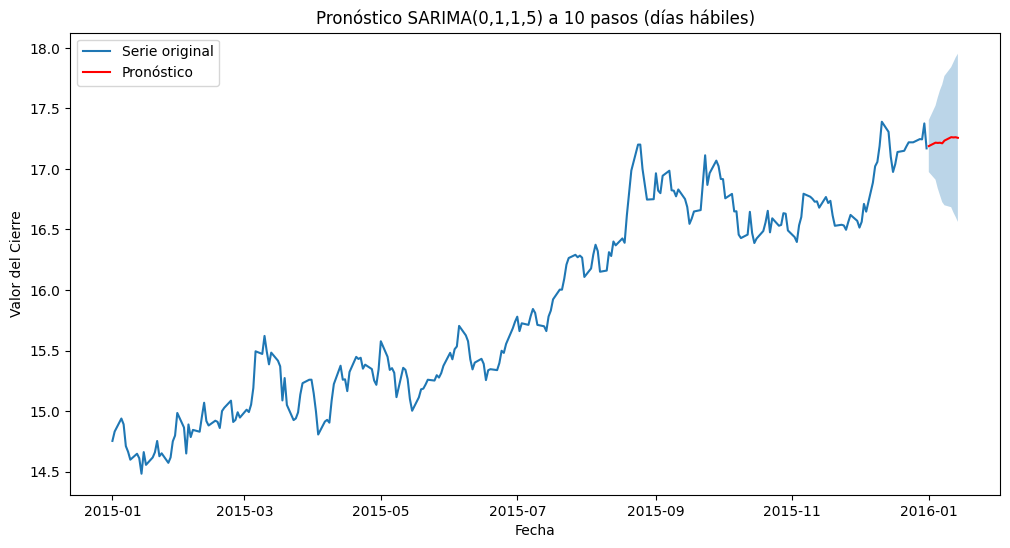

In [ ]:
plt.figure(figsize=(12,6))

# Serie original
plt.plot(serie_2015.index, serie_2015.values, label='Serie original')

# Pronóstico
plt.plot(forecast_index, forecast_mean, label='Pronóstico', color='red')

# Intervalos de confianza
plt.fill_between(
    forecast_index,
    conf_int.iloc[:, 0],  # límite inferior
    conf_int.iloc[:, 1],  # límite superior
    alpha=0.3
)

plt.title('Pronóstico SARIMA(0,1,1,5) a 10 pasos (días hábiles)')
plt.xlabel('Fecha')
plt.ylabel('Valor del Cierre')
plt.legend()
plt.show()

# Métricas de error MAPE

In [ ]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Función MAPE
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Período de comparación (últimos 10 datos reales)
h = 10
y_true = serie_2015[-h:]

# ----------- ARMA(2,1) -----------
# ARMA debe ajustarse a la serie original, no a la diferenciada:
modelo_arma = ARIMA(serie_2015, order=(2,0,1))
res_arma = modelo_arma.fit()

pred_arma = res_arma.get_forecast(steps=h).predicted_mean
pred_arma.index = y_true.index  # mismo índice

mape_arma = mape(y_true, pred_arma)

# ----------- ARIMA(2,1,1) -----------
pred_arima = resultado_arima_211.get_forecast(steps=h).predicted_mean
pred_arima.index = y_true.index

mape_arima = mape(y_true, pred_arima)

# ----------- SARIMA(1,1,0)(0,1,1,5) -----------
pred_sarima = resultado_sarima.get_forecast(steps=h).predicted_mean
pred_sarima.index = y_true.index

mape_sarima = mape(y_true, pred_sarima)

# ----------- RESULTADOS -----------
print("MAPE comparativo:")
print(f"ARMA(2,1): {mape_arma:.4f}%")
print(f"ARIMA(2,1,1): {mape_arima:.4f}%")
print(f"SARIMA(1,1,0)(0,1,1,5): {mape_sarima:.4f}%")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


MAPE comparativo:
ARMA(2,1): 0.5788%
ARIMA(2,1,1): 0.3607%
SARIMA(1,1,0)(0,1,1,5): 0.2340%


De acuerdo con el MAPE comparativo, el modelo SARIMA(1,1,0)(0,1,1,5) presentó el menor error porcentual (0.234%), por lo que resulta ser el modelo con mejor capacidad predictiva entre los probados

In [ ]:
# Imprimir los valores reales en las fechas que predijo el modelo
reales_en_fechas_pred = series.reindex(forecast_index)

print("Valores reales en las fechas predichas:")
print(reales_en_fechas_pred)

Valores reales en las fechas predichas:
2016-01-01    17.1700
2016-01-04    17.3044
2016-01-05    17.3367
2016-01-06    17.5300
2016-01-07    17.8500
2016-01-08    17.9300
2016-01-11    17.8800
2016-01-12    17.8900
2016-01-13    17.9432
2016-01-14    17.8773
Freq: B, Name: Cierre, dtype: float64


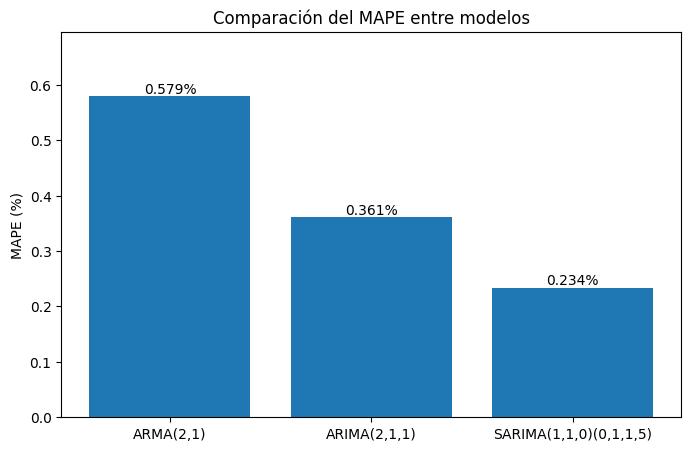

In [ ]:
import matplotlib.pyplot as plt

# Nombres de los modelos
modelos = [
    "ARMA(2,1)",
    "ARIMA(2,1,1)",
    "SARIMA(1,1,0)(0,1,1,5)"
]

# Valores MAPE
mapes = [
    mape_arma,
    mape_arima,
    mape_sarima
]

# Gráfica
plt.figure(figsize=(8,5))
plt.bar(modelos, mapes)
plt.ylabel("MAPE (%)")
plt.title("Comparación del MAPE entre modelos")
plt.ylim(0, max(mapes)*1.2)

# Mostrar valor encima de cada barra
for i, v in enumerate(mapes):
    plt.text(i, v, f"{v:.3f}%", ha='center', va='bottom')

plt.show()